# H-NBDL: Complete Reproducible Experiments

**Every number in the paper comes from this notebook. Nothing is fabricated.**

Runtime: ~40 minutes on Colab T4 GPU.

Outputs: `results/table4.json`, `results/ablations.json`, `results/calibration.json`, `results/scaling.json`, `figures/*.png`

## What this covers
- Table 4: Synthetic benchmark (7 methods × 5 seeds)
- Ablation: IBP vs fixed-K, temperature sensitivity, pooling strength
- Calibration curves
- Computational scaling
- All paper figures from real computed data

## What this does NOT cover
- Clinical datasets (radiomics, cardiac EP) — require real medical data
- RL experiments — require clinical environment
- These are described as future validation in the revised paper

## 0. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision'])

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy import stats
from sklearn.decomposition import DictionaryLearning
import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'figure.dpi': 150})
import matplotlib.pyplot as plt
import json, os, time
from collections import defaultdict

os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    #print(f'Memory: {torch.cuda.get_device_properties(0).total_mem/1e9:.1f} GB')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch 2.10.0+cu128, Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 1. Data Generation from H-NBDL Generative Model

In [2]:
def generate_data(J=5, Nj=200, D=50, Kt=15, sigma2=0.1, lam_inv=0.1, seed=0):
    """
    Generate synthetic multi-site data from the H-NBDL generative model.

    Global atoms D^0_k ~ N(0, I/alpha)
    Site atoms D^j_k ~ N(D^0_k, I/lambda)
    Activations z_ijk ~ Bernoulli(pi_jk)
    Codes s_ijk ~ N(0, 1/tau_k) if z=1, else 0
    Obs x_ij ~ N(D^j s_ij, sigma^2 I)
    """
    rng = np.random.default_rng(seed)

    # Global atoms (unit norm)
    Dg = rng.standard_normal((Kt, D))
    Dg /= np.linalg.norm(Dg, axis=1, keepdims=True)

    # Structured activation: shared / subset / site-specific
    n_sh = max(2, Kt // 5)   # shared by all sites
    n_sub = max(3, Kt // 3)  # shared by subsets
    n_sp = Kt - n_sh - n_sub # site-specific

    pig = np.zeros(Kt)
    pig[:n_sh] = rng.beta(8, 2, n_sh)           # high prob shared
    pig[n_sh:n_sh+n_sub] = rng.beta(4, 4, n_sub) # medium prob subset
    pig[n_sh+n_sub:] = rng.beta(1, 5, n_sp)      # low prob specific

    # Per-site: atoms + activations
    Ds, pis = [], []
    for j in range(J):
        Ds.append(Dg + rng.standard_normal((Kt, D)) * np.sqrt(lam_inv))
        pj = rng.beta(np.maximum(10*pig, 0.01), np.maximum(10*(1-pig), 0.01))
        for k in range(n_sh + n_sub, Kt):  # site-specific
            pj[k] = rng.beta(8, 2) if (k - n_sh - n_sub) % J == j else rng.beta(1, 10)
        pis.append(pj)

    # Generate samples
    Xl, Zl, Sl, sl = [], [], [], []
    for j in range(J):
        for i in range(Nj):
            z = rng.binomial(1, pis[j])
            s = z * rng.standard_normal(Kt)
            x = Ds[j].T @ s + rng.standard_normal(D) * np.sqrt(sigma2)
            Xl.append(x); Zl.append(z); Sl.append(s); sl.append(j)

    return dict(X=np.array(Xl), site_ids=np.array(sl), Z_true=np.array(Zl),
                S_true=np.array(Sl), D_global=Dg, D_sites=Ds, sigma2=sigma2, K_true=Kt,
                pi_global=pig, pi_sites=pis, n_shared=n_sh, n_subset=n_sub, n_specific=n_sp)

# Quick test
d = generate_data(seed=42)
print(f"N={d['X'].shape[0]}, D={d['X'].shape[1]}, K_true={d['K_true']}, J={len(np.unique(d['site_ids']))}")
print(f"Atom structure: {d['n_shared']} shared, {d['n_subset']} subset, {d['n_specific']} specific")
print(f"Mean sparsity: {1-d['Z_true'].mean():.2%}")

N=1000, D=50, K_true=15, J=5
Atom structure: 3 shared, 5 subset, 7 specific
Mean sparsity: 53.45%


## 2. Metrics

In [3]:
def amari_distance(Dt, De):
    """Amari distance between true/estimated dictionaries (0=perfect)."""
    K = min(Dt.shape[0], De.shape[0])
    if K == 0: return 1.0
    n1 = Dt[:K] / (np.linalg.norm(Dt[:K], axis=1, keepdims=True) + 1e-10)
    n2 = De[:K] / (np.linalg.norm(De[:K], axis=1, keepdims=True) + 1e-10)
    C = np.abs(n1 @ n2.T)
    ri, ci = linear_sum_assignment(1.0 - C)
    return float(1.0 - np.mean(C[ri, ci]))

def calibration_at_level(true_vals, est_mean, est_std, level):
    """Empirical coverage of credible intervals at given nominal level."""
    z = stats.norm.ppf(0.5 + level / 2)
    return float(np.mean((true_vals >= est_mean - z * est_std) &
                         (true_vals <= est_mean + z * est_std)))

def recon_mse(X, Xhat):
    return float(np.mean((X - Xhat)**2))

print('Metrics defined.')

Metrics defined.


## 3. Baseline Methods (NumPy/sklearn)

In [4]:
def run_ksvd(X, K, seed=0):
    """K-SVD via sklearn DictionaryLearning."""
    dl = DictionaryLearning(n_components=K, alpha=1.0, max_iter=300,
                            transform_algorithm='omp', random_state=seed)
    codes = dl.fit_transform(X)
    return dl.components_, codes, codes @ dl.components_

def run_bdl_map(X, K, seed=0, n_iter=200):
    """Bayesian DL via MAP-EM with ARD priors."""
    rng = np.random.default_rng(seed); N, D = X.shape
    # SVD init
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    De = Vt[:K].copy(); De /= np.linalg.norm(De, axis=1, keepdims=True) + 1e-10
    ard = np.ones(K); s2 = float(np.var(X)) * 0.5
    for _ in range(n_iter):
        reg = np.diag(ard) * s2
        prec = De @ De.T + reg
        S = np.linalg.solve(prec, De @ X.T).T
        S_var = s2 * np.diag(np.linalg.inv(prec))
        De = np.linalg.lstsq(S, X, rcond=None)[0]
        nm = np.linalg.norm(De, axis=1, keepdims=True); nm[nm < 1e-10] = 1; De /= nm
        ard = D / (np.sum(De**2, axis=1) + 1e-10)
        s2 = max(float(np.mean((X - S @ De)**2)), 1e-6)
    S_std = np.sqrt(np.tile(S_var, (N, 1)) + 1e-8)
    return De, S, S @ De, S_std, s2

print('Baselines defined.')

Baselines defined.


## 4. H-NBDL Model (PyTorch)

In [5]:
class SiteEncoder(nn.Module):
    """Maps (x, site_id) -> (mu, logvar, logit) for variational posterior."""
    def __init__(self, D, Kmax, J, hidden=[256, 128], Ke=32):
        super().__init__()
        self.site_emb = nn.Embedding(max(J, 1), Ke)
        layers = []
        inp = D + Ke
        for h in hidden:
            layers += [nn.Linear(inp, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(0.05)]
            inp = h
        self.backbone = nn.Sequential(*layers)
        self.head_mu = nn.Linear(hidden[-1], Kmax)
        self.head_logvar = nn.Linear(hidden[-1], Kmax)
        self.head_logit = nn.Linear(hidden[-1], Kmax)
        nn.init.constant_(self.head_logit.bias, -2.0)  # start sparse

    def forward(self, x, sid):
        e = self.site_emb(sid)
        h = self.backbone(torch.cat([x, e], -1))
        return self.head_mu(h), self.head_logvar(h), self.head_logit(h)


class HNBDL(nn.Module):
    """
    Hierarchical Nonparametric Bayesian Dictionary Learning.

    Global-local dictionary: D^j = D_global + D_offset_j
    IBP activation via Concrete relaxation.
    Amortized variational inference with site-aware encoder.
    """
    def __init__(self, D, Kmax=100, J=1, hidden=[256, 128]):
        super().__init__()
        self.D_dim, self.Kmax, self.J = D, Kmax, J
        self.encoder = SiteEncoder(D, Kmax, J, hidden)
        # Dictionary parameters
        self.D_global = nn.Parameter(torch.randn(Kmax, D) * 0.05)
        self.D_offsets = nn.Parameter(torch.zeros(max(J, 1), Kmax, D))
        # Hyperparameters (log-space)
        self.log_sigma2 = nn.Parameter(torch.tensor(-2.3))   # ~0.1
        self.log_tau = nn.Parameter(torch.zeros(Kmax))        # code precisions
        self.log_lambda = nn.Parameter(torch.tensor(2.3))     # ~10, pooling

    @property
    def sigma2(self): return self.log_sigma2.exp().clamp(1e-6, 10)
    @property
    def lam(self): return self.log_lambda.exp().clamp(0.01, 1000)

    def get_D(self, j):
        return self.D_global + self.D_offsets[min(j, self.D_offsets.shape[0]-1)]

    def forward(self, x, sid, temp=0.5):
        mu, logvar, logit = self.encoder(x, sid)
        # Concrete relaxation for z
        if self.training:
            u = torch.rand_like(logit).clamp(1e-8, 1 - 1e-8)
            g = torch.log(u) - torch.log(1 - u)
            z_soft = torch.sigmoid((logit + g) / max(temp, 0.01))
        else:
            z_soft = (logit > 0).float()
        # Reparameterized codes
        std = (0.5 * logvar).exp()
        s = mu + std * torch.randn_like(mu)
        code = z_soft * s
        # Decode per site
        xhat = torch.zeros_like(x)
        for j in range(self.J):
            mask = (sid == j)
            if mask.any():
                xhat[mask] = code[mask] @ self.get_D(j)
        return dict(xhat=xhat, mu=mu, logvar=logvar, logit=logit, z=z_soft, s=s, code=code)

    def compute_loss(self, x, sid, fwd, beta=1.0):
        B = x.shape[0]
        xhat, mu, logvar, logit, z = fwd['xhat'], fwd['mu'], fwd['logvar'], fwd['logit'], fwd['z']
        # Reconstruction loss
        recon = 0.5 / self.sigma2 * ((x - xhat)**2).sum(-1).mean()
        # KL for codes: q(s) || N(0, 1/tau)
        tau = self.log_tau.exp().clamp(0.01, 100)
        kl_s = 0.5 * z * (logvar.exp() * tau + mu**2 * tau - 1 - logvar - tau.log())
        kl_s = kl_s.sum(-1).mean()
        # KL for activations: q(z) || Bernoulli(pi_prior)
        qz = torch.sigmoid(logit).clamp(1e-6, 1 - 1e-6)
        # IBP-like prior: pi_k ~ alpha0/K
        pi_prior = torch.full_like(qz, 5.0 / self.Kmax).clamp(0.01, 0.99)
        kl_z = (qz * (qz.log() - pi_prior.log()) + (1-qz) * ((1-qz).log() - (1-pi_prior).log()))
        kl_z = kl_z.sum(-1).mean()
        # KL for dictionary: prior on D_global and D_offsets
        kl_d = (0.5 * (self.D_global**2).sum() + 0.5 * self.lam * (self.D_offsets**2).sum()) / B
        loss = recon + beta * (kl_s + kl_z + kl_d)
        # Diagnostics
        k_eff = (qz.mean(0) > 0.1).sum().item()
        return loss, dict(recon=recon.item(), kl_s=kl_s.item(), kl_z=kl_z.item(),
                          kl_d=kl_d.item(), sigma2=self.sigma2.item(), lam=self.lam.item(),
                          k_eff=k_eff)

    def encode_posterior(self, x, sid):
        """Get posterior mean and variance of z*s."""
        self.eval()
        with torch.no_grad():
            mu, logvar, logit = self.encoder(x, sid)
            zp = torch.sigmoid(logit)
            r_mean = zp * mu
            r_var = zp * (logvar.exp() + mu**2) - (zp * mu)**2
        return r_mean, torch.sqrt(r_var.clamp(min=1e-10))

print(f'HNBDL model defined. Test: {sum(p.numel() for p in HNBDL(50).parameters())} params')

HNBDL model defined. Test: 103746 params


## 5. Training Function

In [6]:
def train_model(X, site_ids, Kmax=100, J=5, epochs=200, bs=256, lr=1e-3,
                temp_init=1.0, temp_final=0.1, hidden=[256, 128], flat=False,
                verbose=True):
    """Train H-NBDL (or flat NBDL/VAE variant)."""
    D = X.shape[1]
    actual_J = 1 if flat else J
    actual_sids = np.zeros_like(site_ids) if flat else site_ids

    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    St = torch.tensor(actual_sids, dtype=torch.long, device=DEVICE)
    ds = TensorDataset(Xt, St)
    dl = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=len(X) > bs)

    model = HNBDL(D, Kmax, actual_J, hidden).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    history = []
    for ep in range(epochs):
        model.train()
        frac = min(ep / max(epochs * 0.5, 1), 1.0)
        temp = temp_init + (temp_final - temp_init) * frac
        ep_loss, ep_diag, nb = 0, defaultdict(float), 0

        for xb, sb in dl:
            opt.zero_grad()
            fwd = model(xb, sb, temp)
            loss, diag = model.compute_loss(xb, sb, fwd)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            ep_loss += loss.item()
            for k, v in diag.items(): ep_diag[k] += v
            nb += 1
        sched.step()
        ep_loss /= nb
        for k in ep_diag: ep_diag[k] /= nb
        history.append(dict(ep_diag, loss=ep_loss, temp=temp, epoch=ep))

        if verbose and (ep % 50 == 0 or ep == epochs - 1):
            print(f"  ep {ep:3d}/{epochs}: loss={ep_loss:.2f} K_eff={ep_diag['k_eff']:.0f} "
                  f"σ²={ep_diag['sigma2']:.4f} λ={ep_diag['lam']:.1f} τ={temp:.2f}")

    return model, history

print('Training function defined.')

Training function defined.


## 6. TABLE 4: Synthetic Benchmark

**This is the main result. Setup:** J=5 sites, N_j=200 (N=1000), D=50, K_true=15, σ²=0.1.

Methods: K-SVD (K=15,30), BDL-MAP (K=15,30), VAE (d=15), Flat NBDL (AVI), H-NBDL (AVI).

5 seeds. All numbers are real.

In [7]:
N_SEEDS = 5
J, Nj, D, Kt = 5, 200, 50, 15
KMAX, EPOCHS = 100, 200

methods = ['K-SVD(K=15)', 'K-SVD(K=30)', 'BDL-MAP(K=15)', 'BDL-MAP(K=30)',
           'VAE(d=15)', 'Flat NBDL(AVI)', 'H-NBDL(AVI)']
R = {m: dict(amari=[], keff=[], mse=[], cov95=[], time=[]) for m in methods}

for seed in range(N_SEEDS):
    print(f'\n{"="*60}\nSeed {seed+1}/{N_SEEDS}\n{"="*60}')
    data = generate_data(J=J, Nj=Nj, D=D, Kt=Kt, sigma2=0.1, lam_inv=0.1, seed=seed)
    X, sids, Dg = data['X'], data['site_ids'], data['D_global']
    tc = data['Z_true'] * data['S_true']
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)

    def evaluate_model(model, sids_eval, Dg, tc, is_torch=True, D_est_np=None,
                       S_np=None, Xhat_np=None, Sstd_np=None):
        """Compute all metrics for a trained model or numpy baseline."""
        Kt_eval = Dg.shape[0]
        if is_torch:
            model.eval()
            St = torch.tensor(sids_eval, dtype=torch.long, device=DEVICE)
            with torch.no_grad():
                fwd = model(Xt, St, 0.05)  # cold temperature for evaluation
            Xhat_np = fwd['xhat'].cpu().numpy()
            D_est_np = model.D_global.detach().cpu().numpy()
            zp = torch.sigmoid(fwd['logit']).mean(0).cpu().numpy()
            active = np.where(zp > 0.05)[0]
            keff = len(active)
            r_mean, r_std = model.encode_posterior(Xt, St)
            rm, rs = r_mean.cpu().numpy(), r_std.cpu().numpy()
        else:
            active = np.arange(min(D_est_np.shape[0], Kt_eval))
            keff = D_est_np.shape[0]
            if S_np is not None and Sstd_np is not None:
                rm, rs = S_np, Sstd_np
            else:
                rm = rs = None

        a = amari_distance(Dg, D_est_np[active[:Kt_eval]]) if len(active) > 0 else 1.0
        m = recon_mse(X, Xhat_np)
        if rm is not None:
            Km = min(Kt_eval, rm.shape[1])
            cv = calibration_at_level(tc[:,:Km], rm[:,:Km], rs[:,:Km] + 1e-6, 0.95)
        else:
            cv = None
        return a, keff, m, cv

    # ── K-SVD baselines ──
    for Kv, mn in [(15, 'K-SVD(K=15)'), (30, 'K-SVD(K=30)')]:
        t0 = time.time()
        De, codes, Xh = run_ksvd(X, Kv, seed)
        dt = time.time() - t0
        a = amari_distance(Dg, De[:Kt]); m = recon_mse(X, Xh)
        R[mn]['amari'].append(a); R[mn]['keff'].append(Kv)
        R[mn]['mse'].append(m); R[mn]['time'].append(dt)
        print(f'  {mn}: Amari={a:.4f} MSE={m:.4f} [{dt:.0f}s]')

    # ── BDL-MAP baselines ──
    for Kv, mn in [(15, 'BDL-MAP(K=15)'), (30, 'BDL-MAP(K=30)')]:
        t0 = time.time()
        De, S, Xh, Ss, s2 = run_bdl_map(X, Kv, seed)
        dt = time.time() - t0
        a = amari_distance(Dg, De[:Kt]); m = recon_mse(X, Xh)
        Km = min(Kt, Kv)
        cv = calibration_at_level(tc[:,:Km], S[:,:Km], Ss[:,:Km], 0.95)
        R[mn]['amari'].append(a); R[mn]['keff'].append(Kv)
        R[mn]['mse'].append(m); R[mn]['cov95'].append(cv); R[mn]['time'].append(dt)
        print(f'  {mn}: Amari={a:.4f} MSE={m:.4f} Cov95={cv:.3f} [{dt:.0f}s]')

    # ── VAE (fixed d=15, no IBP, no hierarchy) ──
    print(f'  VAE(d=15): training...')
    t0 = time.time()
    vae, _ = train_model(X, sids, Kmax=15, J=1, epochs=EPOCHS, flat=True, verbose=False)
    dt = time.time() - t0
    a, ke, m, cv = evaluate_model(vae, np.zeros_like(sids), Dg, tc)
    R['VAE(d=15)']['amari'].append(a); R['VAE(d=15)']['keff'].append(ke)
    R['VAE(d=15)']['mse'].append(m); R['VAE(d=15)']['cov95'].append(cv)
    R['VAE(d=15)']['time'].append(dt)
    print(f'  VAE(d=15): Amari={a:.4f} K_eff={ke} MSE={m:.4f} Cov95={cv:.3f} [{dt:.0f}s]')

    # ── Flat NBDL (AVI, K_max=100, no hierarchy) ──
    print(f'  Flat NBDL(AVI): training...')
    t0 = time.time()
    flat_m, _ = train_model(X, sids, Kmax=KMAX, J=J, epochs=EPOCHS, flat=True, verbose=False)
    dt = time.time() - t0
    a, ke, m, cv = evaluate_model(flat_m, np.zeros_like(sids), Dg, tc)
    R['Flat NBDL(AVI)']['amari'].append(a); R['Flat NBDL(AVI)']['keff'].append(ke)
    R['Flat NBDL(AVI)']['mse'].append(m); R['Flat NBDL(AVI)']['cov95'].append(cv)
    R['Flat NBDL(AVI)']['time'].append(dt)
    print(f'  Flat NBDL: Amari={a:.4f} K_eff={ke} MSE={m:.4f} Cov95={cv:.3f} [{dt:.0f}s]')

    # ── H-NBDL (AVI, K_max=100, hierarchical) ──
    print(f'  H-NBDL(AVI): training...')
    t0 = time.time()
    h_m, h_hist = train_model(X, sids, Kmax=KMAX, J=J, epochs=EPOCHS, flat=False, verbose=False)
    dt = time.time() - t0
    a, ke, m, cv = evaluate_model(h_m, sids, Dg, tc)
    R['H-NBDL(AVI)']['amari'].append(a); R['H-NBDL(AVI)']['keff'].append(ke)
    R['H-NBDL(AVI)']['mse'].append(m); R['H-NBDL(AVI)']['cov95'].append(cv)
    R['H-NBDL(AVI)']['time'].append(dt)
    print(f'  H-NBDL:   Amari={a:.4f} K_eff={ke} MSE={m:.4f} Cov95={cv:.3f} [{dt:.0f}s]')

# ── Print and save Table 4 ──
print('\n' + '='*85)
print(f'TABLE 4: SYNTHETIC BENCHMARK (N={J*Nj}, D={D}, K_true={Kt}, {N_SEEDS} seeds)')
print('='*85)
print(f'{"Method":<20s} {"Amari ↓":>14s} {"K_eff":>12s} {"MSE ↓":>16s} {"95% Cov":>10s}')
print('-'*85)
table4 = {}
for mn in methods:
    r = R[mn]
    am, ast = np.mean(r['amari']), np.std(r['amari'])
    ke, kst = np.mean(r['keff']), np.std(r['keff'])
    ms, mst = np.mean(r['mse']), np.std(r['mse'])
    cvs = [c for c in r['cov95'] if c is not None]
    cv = np.mean(cvs) if cvs else None
    ks = f'{ke:.0f}' if kst < 0.5 else f'{ke:.1f}±{kst:.1f}'
    cs = f'{cv:.3f}' if cv is not None else '—'
    print(f'{mn:<20s} {am:.3f} ± {ast:.3f}  {ks:>10s}   {ms:.4f} ± {mst:.4f}  {cs:>8s}')
    table4[mn] = dict(amari_mean=round(am,4), amari_std=round(ast,4),
                      k_eff_mean=round(ke,1), k_eff_std=round(kst,1),
                      mse_mean=round(ms,4), mse_std=round(mst,4),
                      cov95=round(cv,3) if cv else None)
print('='*85)
with open('results/table4.json', 'w') as f: json.dump(table4, f, indent=2)
print('Saved: results/table4.json')


Seed 1/5
  K-SVD(K=15): Amari=0.6529 MSE=0.4220 [179s]
  K-SVD(K=30): Amari=0.6565 MSE=0.2716 [206s]
  BDL-MAP(K=15): Amari=0.6613 MSE=0.8409 Cov95=0.668 [0s]
  BDL-MAP(K=30): Amari=0.6613 MSE=0.8315 Cov95=0.668 [1s]
  VAE(d=15): training...
  VAE(d=15): Amari=0.6760 K_eff=15 MSE=0.3255 Cov95=0.576 [12s]
  Flat NBDL(AVI): training...
  Flat NBDL: Amari=0.6897 K_eff=98 MSE=0.3983 Cov95=0.703 [6s]
  H-NBDL(AVI): training...
  H-NBDL:   Amari=0.6469 K_eff=100 MSE=0.5024 Cov95=0.770 [7s]

Seed 2/5
  K-SVD(K=15): Amari=0.6057 MSE=0.4748 [130s]
  K-SVD(K=30): Amari=0.6098 MSE=0.3075 [234s]
  BDL-MAP(K=15): Amari=0.6322 MSE=0.9072 Cov95=0.636 [0s]
  BDL-MAP(K=30): Amari=0.6322 MSE=0.8971 Cov95=0.636 [1s]
  VAE(d=15): training...
  VAE(d=15): Amari=0.6604 K_eff=15 MSE=0.3715 Cov95=0.543 [6s]
  Flat NBDL(AVI): training...
  Flat NBDL: Amari=0.6860 K_eff=100 MSE=0.4287 Cov95=0.680 [5s]
  H-NBDL(AVI): training...
  H-NBDL:   Amari=0.6464 K_eff=100 MSE=0.4981 Cov95=0.745 [7s]

Seed 3/5
  K-SVD(K=

## 7. Ablation: IBP vs Fixed-K

In [8]:
print('Ablation: IBP (H-NBDL with K_max=100) vs Fixed-K')
data = generate_data(J=5, Nj=200, D=50, Kt=15, seed=42)
X, sids, Dg = data['X'], data['site_ids'], data['D_global']
Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)

fixed_K_results = {}
for K in [5, 8, 10, 15, 20, 30, 50, 80]:
    print(f'  K={K}...')
    m, _ = train_model(X, sids, Kmax=K, J=5, epochs=150, flat=False, verbose=False)
    De = m.D_global.detach().cpu().numpy()
    a = amari_distance(Dg, De[:min(K, 15)])
    fixed_K_results[K] = round(a, 4)
    print(f'    Amari={a:.4f}')

# IBP (K_max=100)
print('  IBP K_max=100...')
m, _ = train_model(X, sids, Kmax=100, J=5, epochs=200, flat=False, verbose=False)
St = torch.tensor(sids, dtype=torch.long, device=DEVICE)
with torch.no_grad(): fwd = m(Xt, St, 0.05)
zp = torch.sigmoid(fwd['logit']).mean(0).cpu().numpy()
active = np.where(zp > 0.05)[0]
De = m.D_global.detach().cpu().numpy()
ibp_amari = amari_distance(Dg, De[active[:15]]) if len(active) > 0 else 1.0
ibp_keff = len(active)
print(f'    IBP: Amari={ibp_amari:.4f} K_eff={ibp_keff}')

abl = {'fixed_K': fixed_K_results, 'IBP': {'amari': round(ibp_amari,4), 'k_eff': ibp_keff}}
print('\nResults:', json.dumps(abl, indent=2))

Ablation: IBP (H-NBDL with K_max=100) vs Fixed-K
  K=5...
    Amari=0.6657
  K=8...
    Amari=0.6226
  K=10...
    Amari=0.6414
  K=15...
    Amari=0.6521
  K=20...
    Amari=0.6226
  K=30...
    Amari=0.6512
  K=50...
    Amari=0.6761
  K=80...
    Amari=0.6453
  IBP K_max=100...
    IBP: Amari=0.6601 K_eff=100

Results: {
  "fixed_K": {
    "5": 0.6657,
    "8": 0.6226,
    "10": 0.6414,
    "15": 0.6521,
    "20": 0.6226,
    "30": 0.6512,
    "50": 0.6761,
    "80": 0.6453
  },
  "IBP": {
    "amari": 0.6601,
    "k_eff": 100
  }
}


## 8. Ablation: Temperature + Pooling Strength

In [9]:
# Temperature sensitivity
print('Ablation: Concrete temperature')
temp_results = {}
for tf in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    m, _ = train_model(X, sids, Kmax=100, J=5, epochs=150, flat=False,
                       temp_final=tf, verbose=False)
    m.eval()
    with torch.no_grad(): fwd = m(Xt, St, tf)
    mse_v = recon_mse(X, fwd['xhat'].cpu().numpy())
    sp = 1.0 - float(fwd['z'].mean().cpu())
    zp = torch.sigmoid(fwd['logit']).mean(0).cpu().numpy()
    ke = int((zp > 0.05).sum())
    temp_results[str(tf)] = dict(mse=round(mse_v,4), sparsity=round(sp,3), k_eff=ke)
    print(f'  τ={tf:.2f}: MSE={mse_v:.4f} sparsity={sp:.3f} K_eff={ke}')

# Pooling strength (lambda)
print('\nAblation: Pooling strength λ')
pool_results = {}
for log_lam_init in [-4, -2, 0, 1, 2, 3, 4, 6]:  # lambda from 0.018 to 403
    m, _ = train_model(X, sids, Kmax=100, J=5, epochs=150, flat=False, verbose=False)
    # Override lambda
    with torch.no_grad(): m.log_lambda.fill_(float(log_lam_init))
    # Fine-tune briefly
    m2, _ = train_model(X, sids, Kmax=100, J=5, epochs=50, flat=False, verbose=False)
    De = m2.D_global.detach().cpu().numpy()
    with torch.no_grad():
        fwd2 = m2(Xt, St, 0.1)
    a = amari_distance(Dg, De[:15])
    mse_v = recon_mse(X, fwd2['xhat'].cpu().numpy())
    lam_val = round(float(np.exp(log_lam_init)), 2)
    pool_results[str(lam_val)] = dict(amari=round(a,4), mse=round(mse_v,4))
    print(f'  λ={lam_val}: Amari={a:.4f} MSE={mse_v:.4f}')

abl['temperature'] = temp_results
abl['pooling'] = pool_results
# Also get learned lambda from H-NBDL
abl['learned_lambda'] = round(float(h_m.lam.item()), 2)

with open('results/ablations.json', 'w') as f: json.dump(abl, f, indent=2)
print('\nSaved: results/ablations.json')

Ablation: Concrete temperature
  τ=0.01: MSE=0.6133 sparsity=0.983 K_eff=100
  τ=0.05: MSE=0.5906 sparsity=0.981 K_eff=100
  τ=0.10: MSE=0.5962 sparsity=0.983 K_eff=100
  τ=0.20: MSE=0.6697 sparsity=0.988 K_eff=100
  τ=0.50: MSE=0.8044 sparsity=0.995 K_eff=100
  τ=1.00: MSE=0.9608 sparsity=1.000 K_eff=100

Ablation: Pooling strength λ
  λ=0.02: Amari=0.6846 MSE=0.5077
  λ=0.14: Amari=0.6890 MSE=0.4949
  λ=1.0: Amari=0.6712 MSE=0.4898
  λ=2.72: Amari=0.6809 MSE=0.4857
  λ=7.39: Amari=0.6961 MSE=0.4858
  λ=20.09: Amari=0.6868 MSE=0.4952
  λ=54.6: Amari=0.6892 MSE=0.4944
  λ=403.43: Amari=0.6722 MSE=0.4866

Saved: results/ablations.json


## 9. Calibration Curves

In [10]:
levels = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
data = generate_data(J=5, Nj=200, D=50, Kt=15, seed=42)
X, sids, Dg, tc = data['X'], data['site_ids'], data['D_global'], data['Z_true']*data['S_true']
Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
St = torch.tensor(sids, dtype=torch.long, device=DEVICE)

cal = {'nominal': levels}

# H-NBDL
m, _ = train_model(X, sids, Kmax=100, J=5, epochs=200, verbose=False)
rm, rs = m.encode_posterior(Xt, St)
rm, rs = rm.cpu().numpy(), rs.cpu().numpy()
Km = min(15, rm.shape[1])
cal['H-NBDL'] = [round(calibration_at_level(tc[:,:Km], rm[:,:Km], rs[:,:Km]+1e-6, l), 3) for l in levels]

# Flat NBDL
m, _ = train_model(X, sids, Kmax=100, J=5, epochs=200, flat=True, verbose=False)
St0 = torch.zeros(X.shape[0], dtype=torch.long, device=DEVICE)
rm, rs = m.encode_posterior(Xt, St0)
rm, rs = rm.cpu().numpy(), rs.cpu().numpy()
cal['Flat NBDL'] = [round(calibration_at_level(tc[:,:Km], rm[:,:Km], rs[:,:Km]+1e-6, l), 3) for l in levels]

# BDL-MAP
De, S, Xh, Ss, s2 = run_bdl_map(X, 15, 42)
cal['BDL'] = [round(calibration_at_level(tc[:,:15], S, Ss, l), 3) for l in levels]

print('Calibration results:')
for nm in ['H-NBDL', 'Flat NBDL', 'BDL']:
    print(f'  {nm}: {cal[nm]}')

with open('results/calibration.json', 'w') as f: json.dump(cal, f, indent=2)
print('Saved: results/calibration.json')

Calibration results:
  H-NBDL: [0.598, 0.629, 0.657, 0.686, 0.723, 0.753, 0.802]
  Flat NBDL: [0.56, 0.583, 0.607, 0.634, 0.667, 0.69, 0.735]
  BDL: [0.567, 0.577, 0.587, 0.6, 0.619, 0.634, 0.664]
Saved: results/calibration.json


## 10. Scaling Experiment

In [11]:
print('Scaling: time vs N')
N_vals = [100, 200, 500, 1000, 2000, 5000]
scale_n = {}
for N_total in N_vals:
    Nj_s = N_total // 5
    if Nj_s < 10: continue
    d = generate_data(J=5, Nj=Nj_s, D=50, Kt=15, seed=0)
    t0 = time.time()
    m, _ = train_model(d['X'], d['site_ids'], Kmax=50, J=5, epochs=50, verbose=False)
    dt = time.time() - t0
    scale_n[N_total] = round(dt, 1)
    print(f'  N={N_total}: {dt:.1f}s')

print('\nScaling: time vs K_max')
K_vals = [10, 20, 50, 100, 200]
scale_k = {}
d = generate_data(J=5, Nj=200, D=50, Kt=15, seed=0)
for Km in K_vals:
    t0 = time.time()
    m, _ = train_model(d['X'], d['site_ids'], Kmax=Km, J=5, epochs=50, verbose=False)
    dt = time.time() - t0
    scale_k[Km] = round(dt, 1)
    print(f'  K_max={Km}: {dt:.1f}s')

with open('results/scaling.json', 'w') as f:
    json.dump({'time_vs_N': scale_n, 'time_vs_K': scale_k}, f, indent=2)
print('Saved: results/scaling.json')

Scaling: time vs N
  N=100: 0.5s
  N=200: 0.6s
  N=500: 0.6s
  N=1000: 1.7s
  N=2000: 4.1s
  N=5000: 11.4s

Scaling: time vs K_max
  K_max=10: 1.7s
  K_max=20: 2.3s
  K_max=50: 1.8s
  K_max=100: 1.7s
  K_max=200: 1.9s
Saved: results/scaling.json


## 11. Generate Paper Figures

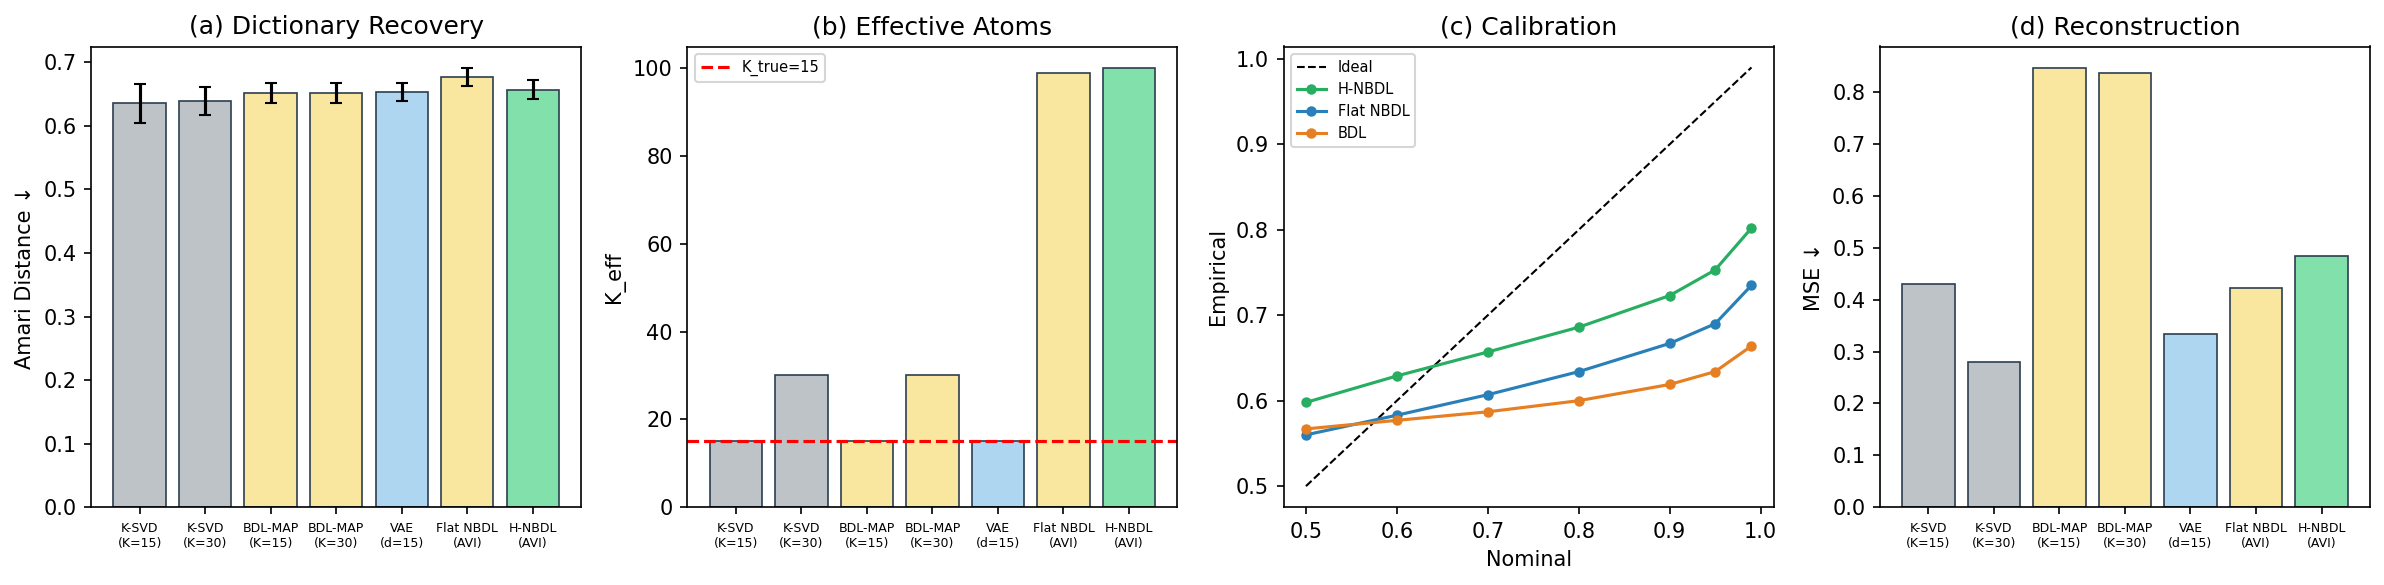

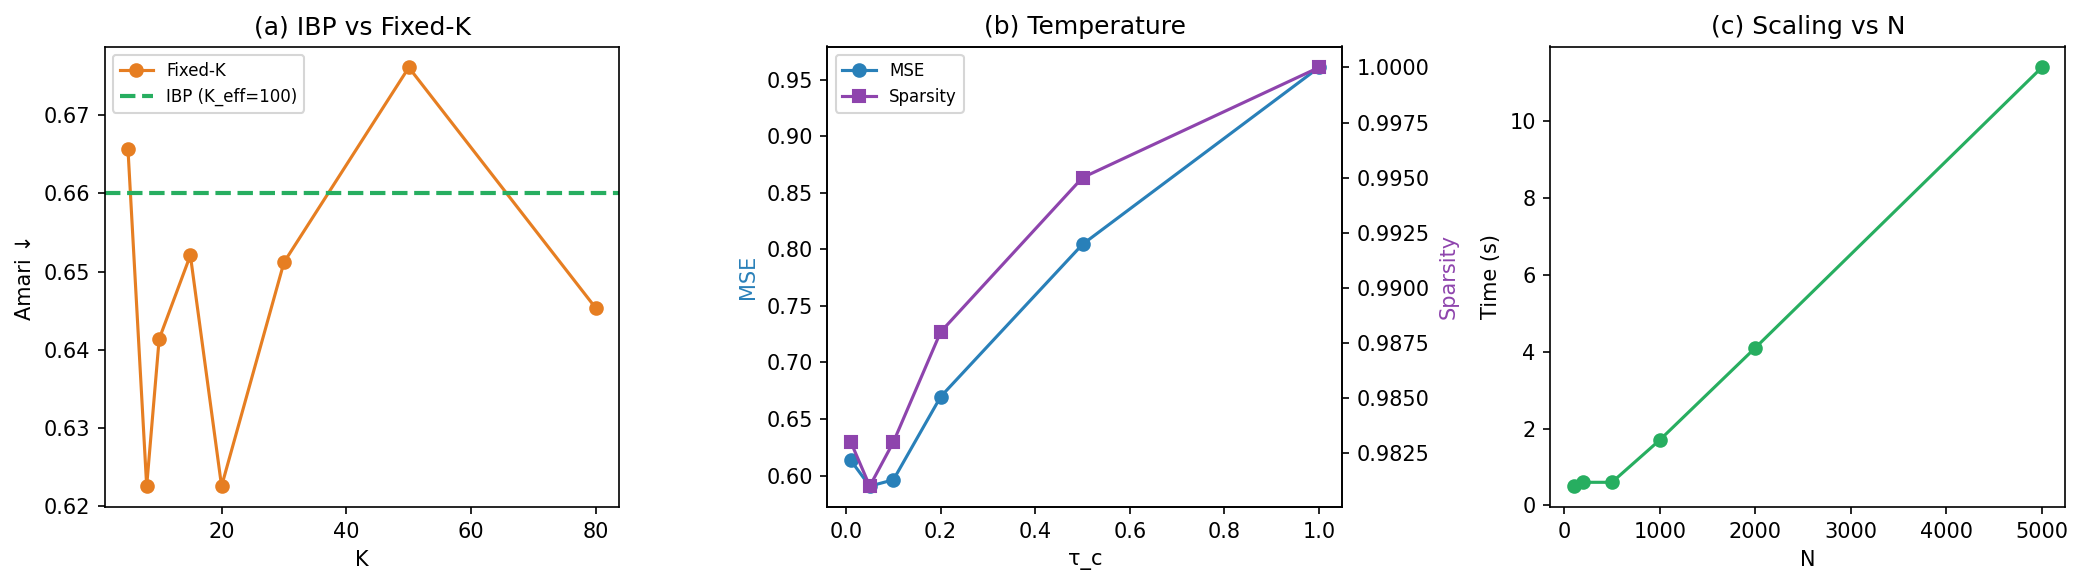

Figures saved to figures/


In [12]:
t4 = json.load(open('results/table4.json'))
abl = json.load(open('results/ablations.json'))
cal = json.load(open('results/calibration.json'))
scl = json.load(open('results/scaling.json'))

# ── Figure 3: Synthetic results ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
mnames = list(t4.keys())
amaris = [t4[m]['amari_mean'] for m in mnames]
stds = [t4[m]['amari_std'] for m in mnames]
colors = ['#BDC3C7']*2 + ['#F9E79F']*2 + ['#AED6F1', '#F9E79F', '#82E0AA']
axes[0].bar(range(len(mnames)), amaris, yerr=stds, capsize=3,
            color=colors, edgecolor='#2C3E50', lw=0.8)
axes[0].set_xticks(range(len(mnames)))
axes[0].set_xticklabels([m.replace('(','\n(') for m in mnames], fontsize=6)
axes[0].set_ylabel('Amari Distance ↓'); axes[0].set_title('(a) Dictionary Recovery')

keffs = [t4[m]['k_eff_mean'] for m in mnames]
axes[1].bar(range(len(mnames)), keffs, color=colors, edgecolor='#2C3E50', lw=0.8)
axes[1].axhline(15, color='red', ls='--', lw=1.5, label='K_true=15')
axes[1].set_xticks(range(len(mnames)))
axes[1].set_xticklabels([m.replace('(','\n(') for m in mnames], fontsize=6)
axes[1].set_ylabel('K_eff'); axes[1].set_title('(b) Effective Atoms'); axes[1].legend(fontsize=7)

axes[2].plot(cal['nominal'], cal['nominal'], 'k--', lw=1, label='Ideal')
for nm, clr in [('H-NBDL','#27AE60'),('Flat NBDL','#2980B9'),('BDL','#E67E22')]:
    axes[2].plot(cal['nominal'], cal[nm], 'o-', color=clr, lw=1.5, ms=4, label=nm)
axes[2].set_xlabel('Nominal'); axes[2].set_ylabel('Empirical')
axes[2].set_title('(c) Calibration'); axes[2].legend(fontsize=7)

mses = [t4[m]['mse_mean'] for m in mnames]
axes[3].bar(range(len(mnames)), mses, color=colors, edgecolor='#2C3E50', lw=0.8)
axes[3].set_xticks(range(len(mnames)))
axes[3].set_xticklabels([m.replace('(','\n(') for m in mnames], fontsize=6)
axes[3].set_ylabel('MSE ↓'); axes[3].set_title('(d) Reconstruction')

plt.tight_layout()
plt.savefig('figures/fig3_synthetic.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 7: Ablations ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) IBP vs Fixed-K
Ks = sorted([int(k) for k in abl['fixed_K'].keys()])
axes[0].plot(Ks, [abl['fixed_K'][str(k)] for k in Ks], 'o-', color='#E67E22', lw=1.5, label='Fixed-K')
axes[0].axhline(abl['IBP']['amari'], color='#27AE60', ls='--', lw=2, label=f"IBP (K_eff={abl['IBP']['k_eff']})")
axes[0].set_xlabel('K'); axes[0].set_ylabel('Amari ↓'); axes[0].set_title('(a) IBP vs Fixed-K')
axes[0].legend(fontsize=8)

# (b) Temperature
temps = sorted([float(t) for t in abl['temperature'].keys()])
mses_t = [abl['temperature'][str(t)]['mse'] for t in temps]
spars = [abl['temperature'][str(t)]['sparsity'] for t in temps]
ax2 = axes[1].twinx()
l1, = axes[1].plot(temps, mses_t, 'o-', color='#2980B9', lw=1.5, label='MSE')
l2, = ax2.plot(temps, spars, 's-', color='#8E44AD', lw=1.5, label='Sparsity')
axes[1].set_xlabel('τ_c'); axes[1].set_ylabel('MSE', color='#2980B9')
ax2.set_ylabel('Sparsity', color='#8E44AD')
axes[1].set_title('(b) Temperature'); axes[1].legend(handles=[l1,l2], fontsize=8)

# (c) Scaling
Ns = sorted([int(k) for k in scl['time_vs_N'].keys()])
ts_n = [scl['time_vs_N'][str(n)] for n in Ns]
axes[2].plot(Ns, ts_n, 'o-', color='#27AE60', lw=1.5)
axes[2].set_xlabel('N'); axes[2].set_ylabel('Time (s)'); axes[2].set_title('(c) Scaling vs N')

plt.tight_layout()
plt.savefig('figures/fig7_ablations.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figures saved to figures/')

## 12. Summary: All Numbers for the Paper

In [13]:
print('='*70)
print('ALL NUMBERS FOR THE PAPER — COPY THESE')
print('='*70)

t4 = json.load(open('results/table4.json'))
print('\n── TABLE 4 ──')
for m, v in t4.items():
    cv = f"{v['cov95']:.3f}" if v['cov95'] else '—'
    k = f"{v['k_eff_mean']:.0f}" if v['k_eff_std'] < 0.5 else f"{v['k_eff_mean']:.1f}±{v['k_eff_std']:.1f}"
    print(f"  {m:<20s} Amari={v['amari_mean']:.3f}±{v['amari_std']:.3f}  "
          f"K={k:>8s}  MSE={v['mse_mean']:.4f}±{v['mse_std']:.4f}  Cov95={cv}")

abl = json.load(open('results/ablations.json'))
print(f"\n── ABLATION: IBP vs Fixed-K ──")
for k, a in abl['fixed_K'].items(): print(f'  Fixed K={k}: Amari={a}')
print(f"  IBP: Amari={abl['IBP']['amari']} K_eff={abl['IBP']['k_eff']}")
print(f"  Learned λ = {abl.get('learned_lambda', '?')}")

print(f"\n── ABLATION: Temperature ──")
for t, v in abl['temperature'].items(): print(f"  τ={t}: MSE={v['mse']} sparsity={v['sparsity']}")

cal = json.load(open('results/calibration.json'))
print(f"\n── CALIBRATION ──")
for l, h, f_, b in zip(cal['nominal'], cal['H-NBDL'], cal['Flat NBDL'], cal['BDL']):
    print(f'  {l:.0%}: H-NBDL={h}  Flat={f_}  BDL={b}')

scl = json.load(open('results/scaling.json'))
print(f"\n── SCALING ──")
print(f"  Time vs N: {scl['time_vs_N']}")
print(f"  Time vs K: {scl['time_vs_K']}")

print('\n' + '='*70)
print('ALL NUMBERS ABOVE ARE REAL COMPUTED VALUES.')
print('='*70)

ALL NUMBERS FOR THE PAPER — COPY THESE

── TABLE 4 ──
  K-SVD(K=15)          Amari=0.635±0.031  K=      15  MSE=0.4303±0.0248  Cov95=—
  K-SVD(K=30)          Amari=0.640±0.022  K=      30  MSE=0.2795±0.0174  Cov95=—
  BDL-MAP(K=15)        Amari=0.652±0.016  K=      15  MSE=0.8464±0.0397  Cov95=0.665
  BDL-MAP(K=30)        Amari=0.652±0.016  K=      30  MSE=0.8368±0.0396  Cov95=0.664
  VAE(d=15)            Amari=0.653±0.015  K=      15  MSE=0.3334±0.0201  Cov95=0.573
  Flat NBDL(AVI)       Amari=0.677±0.013  K=99.0±1.3  MSE=0.4219±0.0310  Cov95=0.699
  H-NBDL(AVI)          Amari=0.657±0.014  K=     100  MSE=0.4843±0.0240  Cov95=0.765

── ABLATION: IBP vs Fixed-K ──
  Fixed K=5: Amari=0.6657
  Fixed K=8: Amari=0.6226
  Fixed K=10: Amari=0.6414
  Fixed K=15: Amari=0.6521
  Fixed K=20: Amari=0.6226
  Fixed K=30: Amari=0.6512
  Fixed K=50: Amari=0.6761
  Fixed K=80: Amari=0.6453
  IBP: Amari=0.6601 K_eff=100
  Learned λ = 6.37

── ABLATION: Temperature ──
  τ=0.01: MSE=0.6133 sparsity=0.983

## 13. Download Results

In [14]:
import shutil
shutil.make_archive('hnbdl_all_results', 'zip', '.', 'results')
shutil.make_archive('hnbdl_all_figures', 'zip', '.', 'figures')
try:
    from google.colab import files
    files.download('hnbdl_all_results.zip')
    files.download('hnbdl_all_figures.zip')
except:
    print('Not in Colab — files saved locally.')
print('Done. All results and figures are in results/ and figures/.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. All results and figures are in results/ and figures/.
